Overall Test Accuracy: 73.44%

Detailed Classification Report:
              precision    recall  f1-score   support

        Bach       1.00      1.00      1.00        13
   Beethoven       0.70      0.93      0.80        30
      Brahms       0.50      0.20      0.29         5
     Cambini       0.50      1.00      0.67         2
      Dvorak       0.00      0.00      0.00         1
       Faure       0.00      0.00      0.00         1
      Mozart       1.00      0.40      0.57         5
       Ravel       0.00      0.00      0.00         1
    Schubert       1.00      0.17      0.29         6

    accuracy                           0.73        64
   macro avg       0.52      0.41      0.40        64
weighted avg       0.76      0.73      0.69        64



/share/pkg.8/python3/3.10.12/install/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/share/pkg.8/python3/3.10.12/install/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/share/pkg.8/python3/3.10.12/install/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

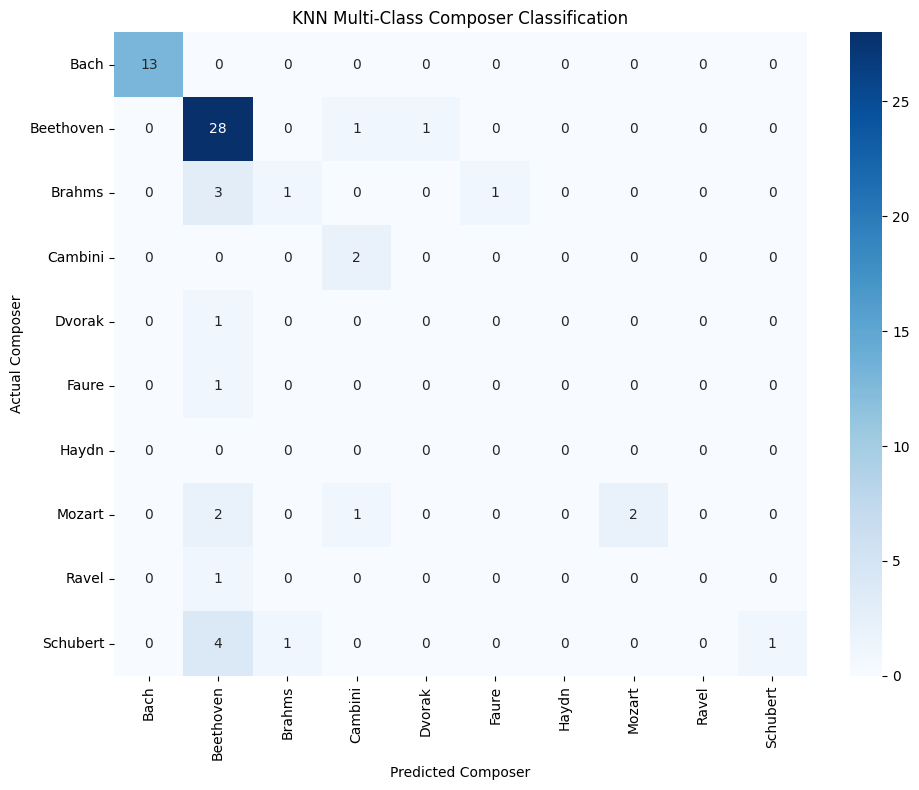

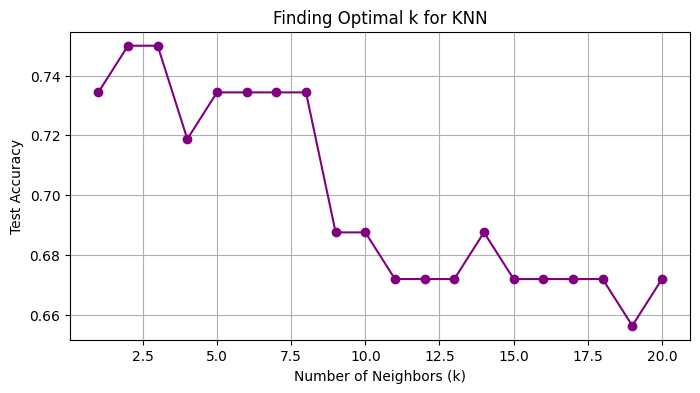


--- Predictions & Uncertainty Metrics for 10 New Pieces ---
  Actual_Composer Predicted_Composer  Correct  Confidence  \
0            Bach               Bach     True       100.0   
1           Haydn             Mozart    False        40.0   
2       Beethoven          Beethoven     True        40.0   
3       Beethoven          Beethoven     True        80.0   
4       Beethoven          Beethoven     True        80.0   
5            Bach               Bach     True       100.0   
6          Mozart          Beethoven    False        40.0   
7            Bach               Bach     True       100.0   
8       Beethoven          Beethoven     True        60.0   
9        Schubert          Beethoven    False        60.0   

   Entropy_Uncertainty_%  Mean_Neighbor_Distance  
0                  -0.00                    1.77  
1                  57.86                    1.54  
2                  45.81                    1.67  
3                  21.73                    1.57  
4           

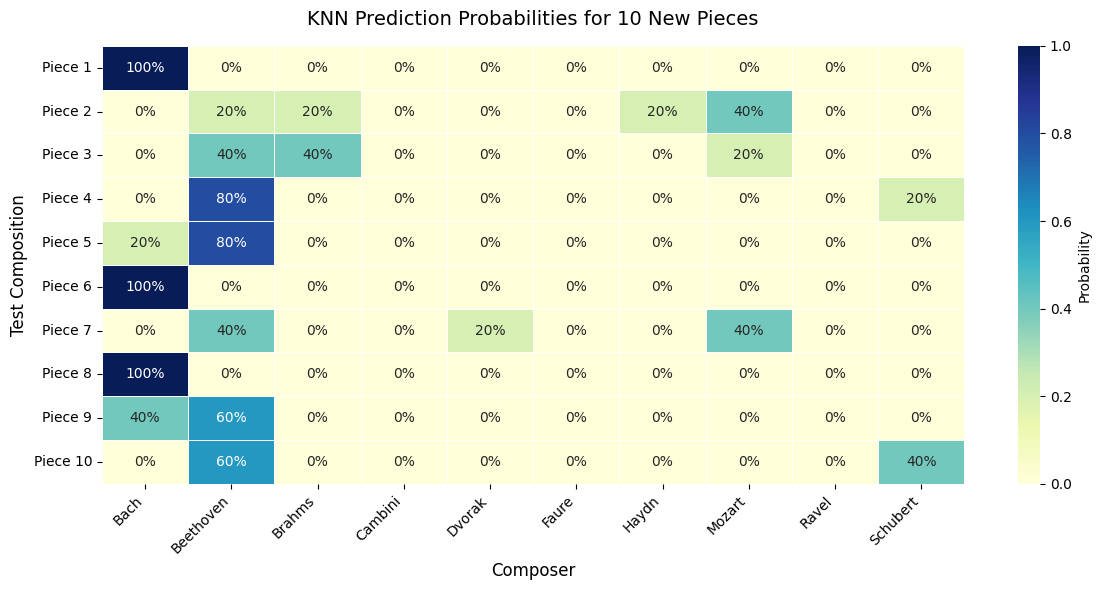

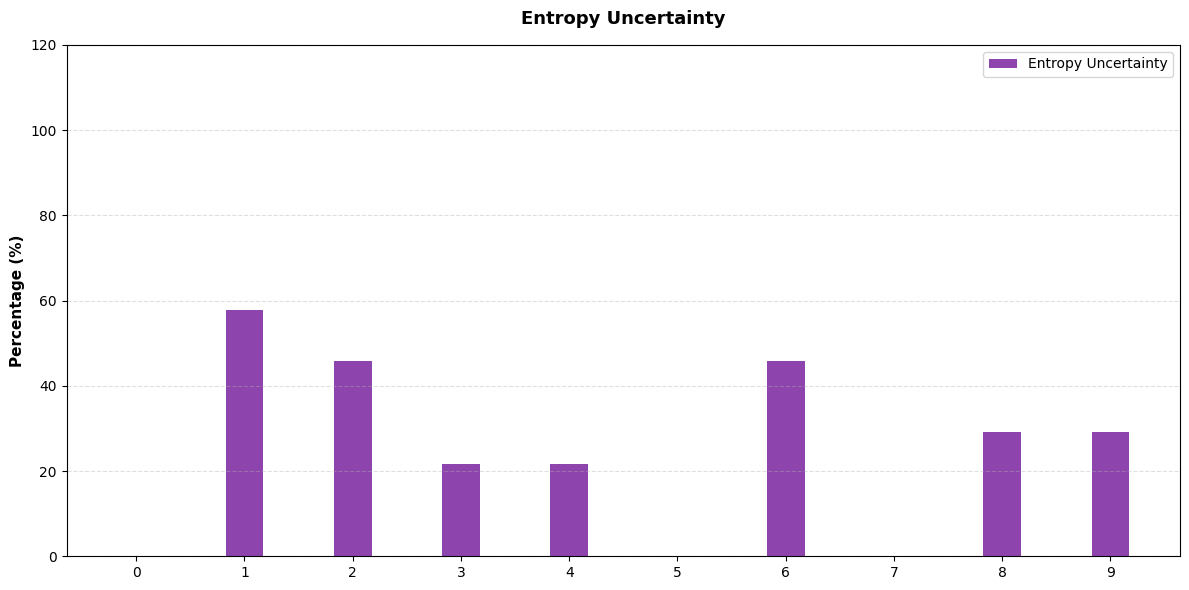

In [12]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# LOAD AND PREPROCESS TRAINING DATA
feature_cols = [
    'pitch_entropy', 'rhythmic_entropy', 'average_interval_size',
    'average_vertical_density', 'average_polyphonic_voices',
    'fractal_dimension', 'num_notes', 'pitch_std', 'pitch_range',
    'number_of_instruments', 'unique_note_values', 'average_beat_gap'
]

folder_path = "composers_csv_sorted/*.csv"
all_files = glob.glob(folder_path)

data_frames = []
for file in all_files:
    df_temp = pd.read_csv(file)
    data_frames.append(df_temp)

full_df = pd.concat(data_frames, ignore_index=True)

X = full_df[feature_cols]
y = full_df['composer']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)


y_pred = knn.predict(X_test_scaled)
print(f"Overall Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel('Predicted Composer')
plt.ylabel('Actual Composer')
plt.title('KNN Multi-Class Composer Classification')
plt.tight_layout()
plt.show()


k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    accuracies.append(acc)

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker='o', color='purple')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy')
plt.title('Finding Optimal k for KNN')
plt.grid(True)
plt.show()



# PREDICT ON 10 NEW UNSEEN PIECES & CALCULATE UNCERTAINTY
new_data_path = "test_data_clean.csv"
new_df = pd.read_csv(new_data_path)

X_new = new_df[feature_cols]
X_new_scaled = scaler.transform(X_new)

# Predict class and probabilities
predictions = knn.predict(X_new_scaled)
probabilities = knn.predict_proba(X_new_scaled)

results_df = new_df.copy()
results_df['Predicted_Composer'] = predictions

results_df['Confidence'] = np.max(probabilities, axis=1) * 100

entropy = -np.sum(probabilities * np.log2(probabilities + 1e-9), axis=1)
max_entropy = np.log2(len(knn.classes_))
results_df['Entropy_Uncertainty_%'] = (entropy / max_entropy) * 100

distances, _ = knn.kneighbors(X_new_scaled)
results_df['Mean_Neighbor_Distance'] = np.mean(distances, axis=1)

df2 = pd.read_csv("test_data_composers.csv")
results_df['Actual_Composer'] = df2['composer']
results_df['Correct'] = results_df['Predicted_Composer'] == results_df['Actual_Composer']

print("\n--- Predictions & Uncertainty Metrics for 10 New Pieces ---")
cols_to_show = [
    'Actual_Composer', 'Predicted_Composer', 'Correct',
    'Confidence', 'Entropy_Uncertainty_%', 'Mean_Neighbor_Distance'
]
if 'title' in results_df.columns:
    cols_to_show.insert(0, 'title')

print(results_df[cols_to_show].round(2))





# HEATMAP VISUALIZATION (PROBABILITIES)

if 'title' in new_df.columns:
    piece_labels = new_df['title']
elif 'filename' in new_df.columns:
    piece_labels = new_df['filename']
else:
    piece_labels = [f"Piece {i+1}" for i in range(len(new_df))]

prob_df = pd.DataFrame(
    probabilities,
    index=piece_labels,
    columns=knn.classes_
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    prob_df,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu",
    cbar_kws={'label': 'Probability'},
    linewidths=0.5
)
plt.title("KNN Prediction Probabilities for 10 New Pieces", fontsize=14, pad=15)
plt.xlabel("Composer", fontsize=12)
plt.ylabel("Test Composition", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()





# PLOT UNCERTAINTY 
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))

bar = ax.bar(x, results_df['Entropy_Uncertainty_%'], 0.35, label='Entropy Uncertainty', color='#8e44ad')

ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax.set_title('Entropy Uncertainty', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_ylim(0, 120)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()